In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

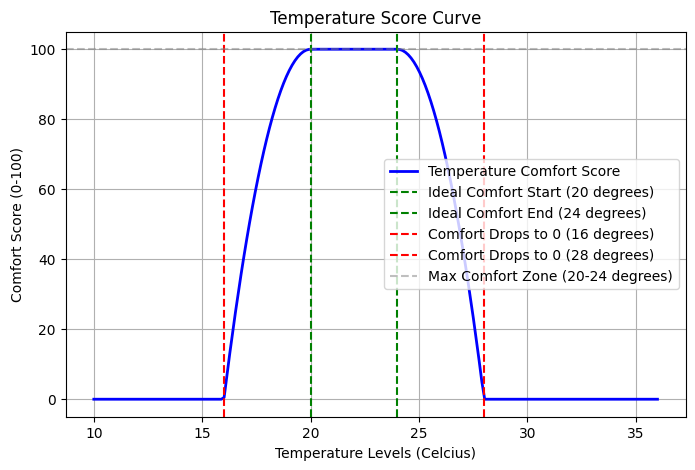

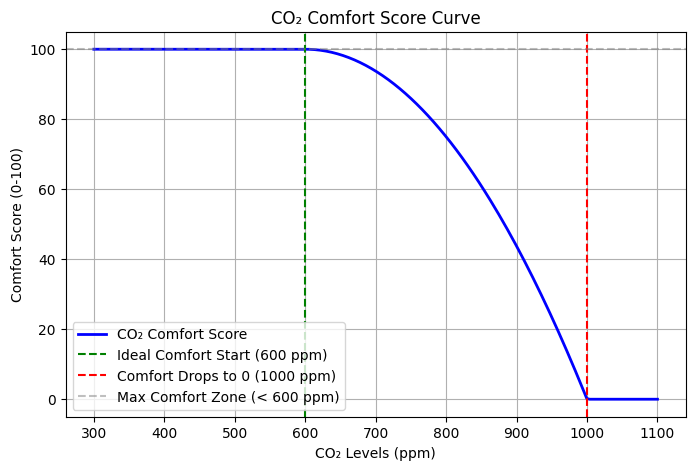

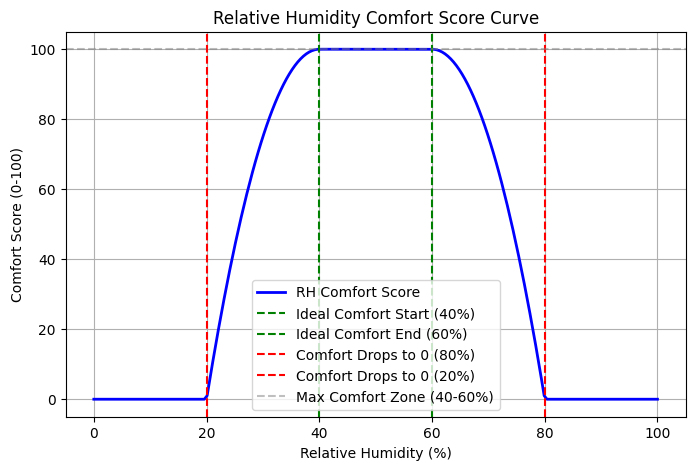

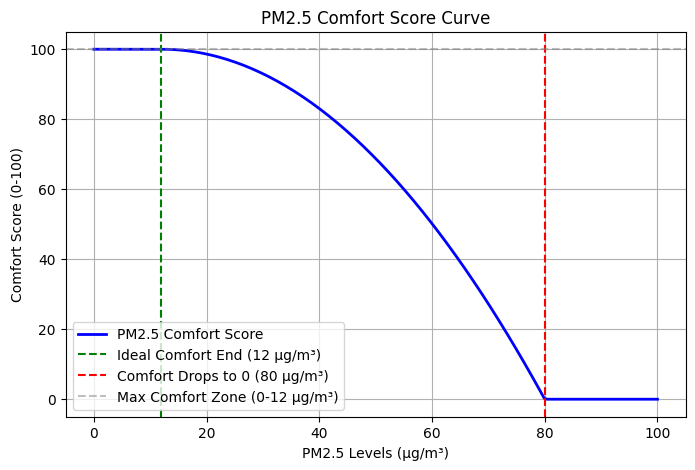

In [3]:
from pythermalcomfort.models import pmv_ppd_iso

dfs = [pd.read_csv('datasets/madalena_processed_30min/E_147.csv'), pd.read_csv('datasets/madalena_processed_30min/E_149.csv'),pd.read_csv('datasets/madalena_processed_30min/E_150.csv'), pd.read_csv('datasets/madalena_processed_30min/E_155.csv')]

def temperature_calc(temp, month):
    if(month == 1 or month == 12 or month == 11 or month == 2 or month == 3):
        if temp <= 16 or temp >= 28:
            return 0
        elif 20 <= temp <= 24:
            return 100
        elif 16 < temp < 20:
            return 100 - ((temp - 20) / (20 - 16))**2 * 100  
        elif 24 < temp < 28:
            return 100 - ((temp - 24) / (28 - 24))**2 * 100 
    else:
        if temp <= 19 or temp >= 31:
            return 0
        elif 23 <= temp <= 27:
            return 100
        elif 19 < temp < 23:
            return 100 - ((temp - 23) / (23 - 19))**2 * 100  
        elif 27 < temp < 31:
            return 100 - ((temp - 27) / (31 - 27))**2 * 100
        
temp_levels_fixed = np.linspace(10, 36, 200)  
temp_scores_fixed = [temperature_calc(temp, 1) for temp in temp_levels_fixed]

plt.figure(figsize=(8, 5))
plt.plot(temp_levels_fixed, temp_scores_fixed, label="Temperature Comfort Score", color="blue", linewidth=2)
plt.axvline(x=20, linestyle="--", color="green", label="Ideal Comfort Start (20 degrees)")
plt.axvline(x=24, linestyle="--", color="green", label="Ideal Comfort End (24 degrees)")
plt.axvline(x=16, linestyle="--", color="red", label="Comfort Drops to 0 (16 degrees)")
plt.axvline(x=28, linestyle="--", color="red", label="Comfort Drops to 0 (28 degrees)")
plt.axhline(y=100, linestyle="--", color="gray", alpha=0.5, label="Max Comfort Zone (20-24 degrees)")
plt.xlabel("Temperature Levels (Celcius)")
plt.ylabel("Comfort Score (0-100)")
plt.title("Temperature Score Curve")
plt.legend()
plt.grid(True)

plt.show()

def co2_comfort_score(co2):
    if co2 >= 1000:
        return 0
    elif co2 <= 600:
        return 100
    elif 600 < co2 < 1000:
        return 100 - ((co2 - 600) / (1000 - 600))**2 * 100 
    # elif 800 < co2 < 1000:
    #     return 100 - ((co2 - 800) / (1000 - 800))**2 * 100  

co2_levels_fixed = np.linspace(300, 1100, 200)  
co2_scores_fixed = [co2_comfort_score(co2) for co2 in co2_levels_fixed]

plt.figure(figsize=(8, 5))
plt.plot(co2_levels_fixed, co2_scores_fixed, label="CO₂ Comfort Score", color="blue", linewidth=2)
plt.axvline(x=600, linestyle="--", color="green", label="Ideal Comfort Start (600 ppm)")
plt.axvline(x=1000, linestyle="--", color="red", label="Comfort Drops to 0 (1000 ppm)")
plt.axhline(y=100, linestyle="--", color="gray", alpha=0.5, label="Max Comfort Zone (< 600 ppm)")
plt.xlabel("CO₂ Levels (ppm)")
plt.ylabel("Comfort Score (0-100)")
plt.title("CO₂ Comfort Score Curve")
plt.legend()
plt.grid(True)

plt.show()

def rh_comfort_score(rh):
    if rh <= 20 or rh >= 80:
        return 0
    elif 40 <= rh <= 60:
        return 100
    elif 20 < rh < 40:
        return 100 - ((rh - 40) / (40 - 20))**2 * 100  
    elif 60 < rh < 80:
        return 100 - ((rh - 60) / (80 - 60))**2 * 100  

rh_levels = np.linspace(0, 100, 200)  
rh_scores = [rh_comfort_score(rh) for rh in rh_levels]


plt.figure(figsize=(8, 5))
plt.plot(rh_levels, rh_scores, label="RH Comfort Score", color="blue", linewidth=2)
plt.axvline(x=40, linestyle="--", color="green", label="Ideal Comfort Start (40%)")
plt.axvline(x=60, linestyle="--", color="green", label="Ideal Comfort End (60%)")
plt.axvline(x=80, linestyle="--", color="red", label="Comfort Drops to 0 (80%)")
plt.axvline(x=20, linestyle="--", color="red", label="Comfort Drops to 0 (20%)")
plt.axhline(y=100, linestyle="--", color="gray", alpha=0.5, label="Max Comfort Zone (40-60%)")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Comfort Score (0-100)")
plt.title("Relative Humidity Comfort Score Curve")
plt.legend()
plt.grid(True)

plt.show()

def pm25_comfort_score(pm25):
    if pm25 >= 80:
        return 0
    elif pm25 <= 12:
        return 100
    else:
        return 100 - ((pm25 - 12) / (80 - 12))**2 * 100  

pm25_levels_fixed = np.linspace(0, 100, 200)  
pm25_scores_fixed = [pm25_comfort_score(pm25) for pm25 in pm25_levels_fixed]


plt.figure(figsize=(8, 5))
plt.plot(pm25_levels_fixed, pm25_scores_fixed, label="PM2.5 Comfort Score", color="blue", linewidth=2)
plt.axvline(x=12, linestyle="--", color="green", label="Ideal Comfort End (12 µg/m³)")
plt.axvline(x=80, linestyle="--", color="red", label="Comfort Drops to 0 (80 µg/m³)")
plt.axhline(y=100, linestyle="--", color="gray", alpha=0.5, label="Max Comfort Zone (0-12 µg/m³)")
plt.xlabel("PM2.5 Levels (µg/m³)")
plt.ylabel("Comfort Score (0-100)")
plt.title("PM2.5 Comfort Score Curve")
plt.legend()
plt.grid(True)

plt.show()


In [23]:
def calculate_overall_comfort(row):
    results = pmv_ppd_iso(
        tdb=row['Tin'],
        tr=row['Tin'],  
        vr=0.1,      
        rh=row['RH'],
        met=1.1,         
        clo=0.5,         
    )
    pmv = results['pmv']
    ppd = results['ppd']
    comfort_pct = 100 - ppd
    return pd.Series({'PMV': pmv, 'PPD': ppd, 'Comfort_pct': comfort_pct})

names = ["E_147", "E_149",'E_150', 'E_155']

def create_comfort_score(dfs):
    for index, df in enumerate(dfs):
        # dfs[index] = calculate_overall_comfort(df)
        df['month'] = pd.to_datetime(df['timestamps']).dt.month
        df[['PMV', 'PPD', 'Overall_Comfort']] = df.apply(calculate_overall_comfort, axis=1)
        print(df.head())
        # dfs[index].to_csv(f"datasets/madalena_processed_30min/{names[index]}.csv")


In [24]:
def plot_comfort_scores(dfs):
    for df in dfs:
        df['timestamps'] = pd.to_datetime(df['timestamps'])
        df['Overall_Comfort'] = df['Overall_Comfort'].fillna(0)
        df_temp = df[:1000]
        plt.figure(figsize=(10, 5))
        plt.plot(df_temp['timestamps'], df_temp['Overall_Comfort'], color='blue', linewidth=2, label="Overall Comfort Score")

        plt.xlabel("Time")
        plt.ylabel("Overall Comfort Score (0-100)")
        plt.title("Overall Comfort Score Over Time")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)

        plt.show()

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\subprocess.py", line 1538, in 

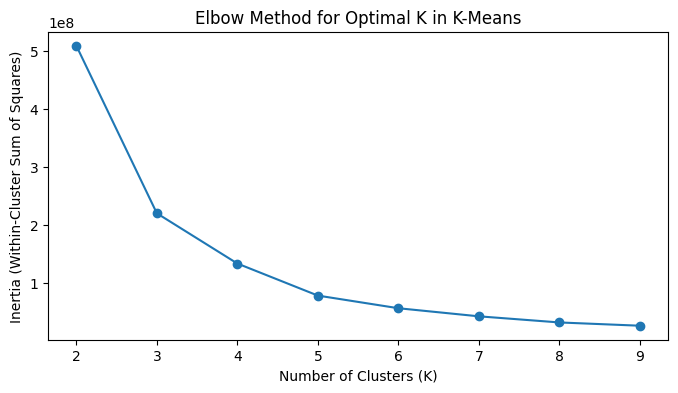

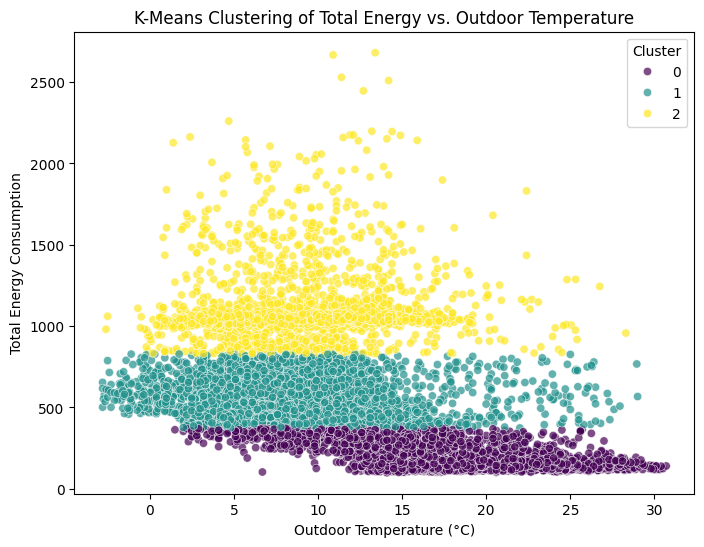

In [6]:
from sklearn.cluster import KMeans
import seaborn as sns

X = dfs[0][['total_energy', 'Tout']].dropna()  

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K in K-Means")
plt.show()

optimal_k = 3  

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
dfs[0]['cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=dfs[0], x="Tout", y="total_energy", hue="cluster", palette="viridis", alpha=0.7)
plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Total Energy Consumption")
plt.title("K-Means Clustering of Total Energy vs. Outdoor Temperature")
plt.legend(title="Cluster")
plt.show()


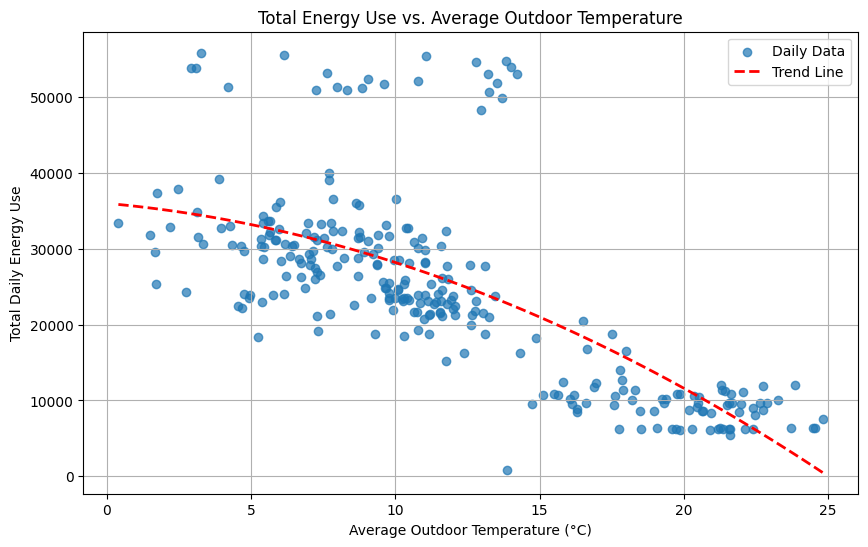

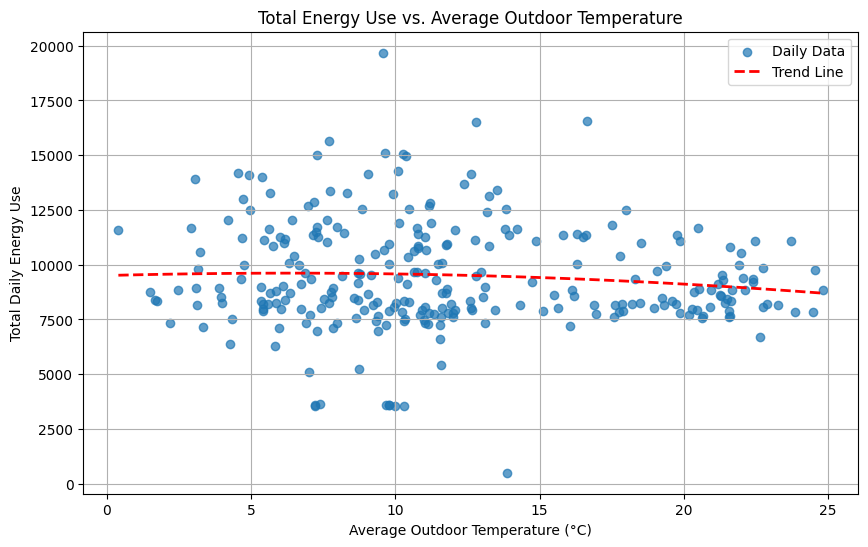

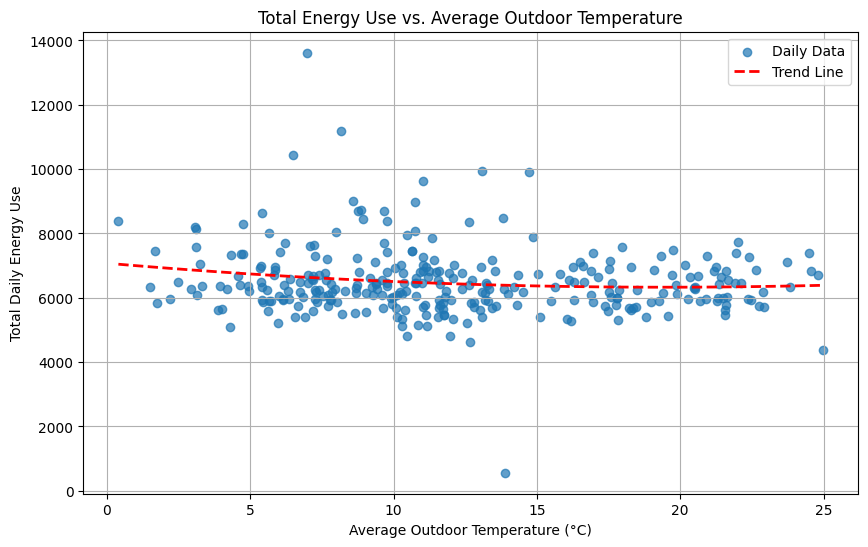

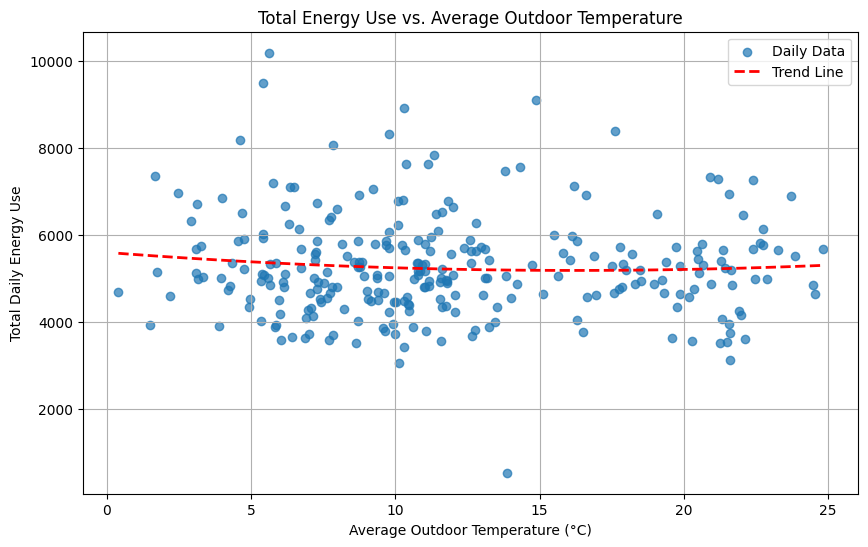

In [8]:
for df in dfs:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    df['date'] = df['timestamp'].dt.date

    daily_data = df.groupby('date').agg(
        total_energy=('total_energy', 'sum'),
        avg_temperature=('Tout', 'mean')
    ).reset_index()

    coeffs = np.polyfit(daily_data['avg_temperature'], daily_data['total_energy'], deg=2)
    poly_eq = np.poly1d(coeffs)

    x_smooth = np.linspace(daily_data['avg_temperature'].min(), daily_data['avg_temperature'].max(), 100)
    y_smooth = poly_eq(x_smooth)

    plt.figure(figsize=(10, 6))
    plt.scatter(daily_data['avg_temperature'], daily_data['total_energy'], alpha=0.7, label='Daily Data')
    plt.plot(x_smooth, y_smooth, color='red', linestyle='--', linewidth=2, label='Trend Line')
    plt.xlabel('Average Outdoor Temperature (°C)')
    plt.ylabel('Total Daily Energy Use')
    plt.title('Total Energy Use vs. Average Outdoor Temperature')
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
# df = dfs[0].copy()

scaler = MinMaxScaler()
scaled_cols = ['Tout', 'total_energy', 'hvac_lag', 'Tout_hourly_mean', 'energy_rolling_mean', 'energy_rolling_max', 'max_Tout', 'min_Tout']

def preprocess_data(df, limited_data = False, custom_scaled_cols = []):
    if not limited_data:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.drop(columns=['Unnamed: 0'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df = df.sort_index()
        df['energy_rolling_max'] = df['total_energy'].rolling(window=48).max().ffill().bfill()
        df['temp_diff'] = df['Tin'] - df['Tout'] 
        df['hour'] = df.index.hour 
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24) 
        df['max_Tout'] = df['Tout'].rolling(window=48).max().ffill().bfill()
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['energy_rolling_mean'] = df['total_energy'].rolling(window=4).mean().fillna(0)
        df['hvac_lag'] = df['total_energy'].shift(1).fillna(0) 
        df['Tout_hourly_mean'] = df['Tout'].rolling(window=2).mean().fillna(0)
        df['season'] = df.index.month.map({1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3, 12: 1})
        df['min_Tout'] = df['Tout'].rolling(window=48).min().ffill().bfill()

    if custom_scaled_cols:
        df[custom_scaled_cols] = scaler.fit_transform(df[custom_scaled_cols])
    else:
        df[scaled_cols] = scaler.fit_transform(df[scaled_cols])
    return df

# df = preprocess_data(df)

def apply_kmeans(df, columns, n_clusters=3):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) 
    df['cluster_kmeans'] = kmeans.fit_predict(df[columns])
    return df, kmeans

# df, kmeans_model = apply_kmeans(df, scaled_cols)

def apply_gmm(df, columns, n_components=3):
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    df['cluster_gmm'] = gmm.fit_predict(df[columns])
    return df, gmm

def apply_dbscan(df, columns, eps=0.5, min_samples=5):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    df['cluster_dbscan'] = dbscan.fit_predict(df[columns])
    return df, dbscan
# df, gmm_model = apply_gmm(df ,scaled_cols)
# df, db_model = apply_dbscan(df ,scaled_cols)


def estimate_hvac_load(df):
    baseline_cluster = df.groupby('cluster_kmeans')['total_energy'].mean().idxmin()
    baseline_cluster_gmm = df.groupby('cluster_gmm')['total_energy'].mean().idxmin()
    baseline_cluster_db = df.groupby('cluster_dbscan')['total_energy'].mean().idxmin()

    df['baseline_load'] = df['total_energy'].where(df['cluster_kmeans'] == baseline_cluster)
    df['baseline_load_gmm'] = df['total_energy'].where(df['cluster_gmm'] == baseline_cluster_gmm)
    # df['baseline_load_db'] = df['total_energy'].where(df['cluster_dbscan'] == baseline_cluster_db)

    df['baseline_load'] = df['baseline_load'].fillna(method='ffill').ffill().bfill()
    df['baseline_load_gmm'] = df['baseline_load_gmm'].fillna(method='ffill').ffill().bfill()
    # df['baseline_load_db'] = df['baseline_load_db'].fillna(method='ffill').ffill().bfill()
    df['hvac_load'] = df['total_energy'] - 1.5*df['baseline_load']
    df['hvac_load'] = df['hvac_load'].clip(lower=0)

    df['hvac_load_gmm'] = df['total_energy'] - df['baseline_load_gmm']
    df['hvac_load_gmm'] = df['hvac_load_gmm'].clip(lower=0)
    
    cluster_means = df.groupby('cluster_dbscan')['total_energy'].mean().sort_values()
    baseline_clusters = cluster_means.head(2).index.tolist()
    df['baseline_load_dbscan'] = df['total_energy'].where(df['cluster_dbscan'].isin(baseline_clusters))
    df['baseline_load_dbscan'] = df['baseline_load_dbscan'].fillna(method='ffill').fillna(method='bfill')
    df['hvac_load_db'] = (df['total_energy'] - df['baseline_load_dbscan']).clip(lower=0)
    # df['hvac_load_db'] = df['total_energy'] - df['baseline_load_db']
    # df['hvac_load_db'] = df['hvac_load_db'].clip(lower=0)
    df["heat_pump_active"] = df["hvac_load"] > 20
    return df

def inverse_transform(df, custom_scaled_cols = []):
    df_copy = df.copy()
    if custom_scaled_cols:
        df_copy[custom_scaled_cols] = scaler.inverse_transform(df_copy[custom_scaled_cols])
    else:
        df_copy[['Tout','total_energy','hvac_lag', 'Tout_hourly_mean', 'energy_rolling_mean', 'energy_rolling_max', 'max_Tout', 'min_Tout']] = scaler.inverse_transform(df_copy[['Tout', 'total_energy', 'hvac_lag', 'Tout_hourly_mean', 'energy_rolling_mean', 'energy_rolling_max', 'max_Tout', 'min_Tout']])
    return df_copy

# df = inverse_transform(df)
# df = estimate_hvac_load(df)


def plot_clusters(df, limited_data=False, method='kmeans'):
    if limited_data:
        plt.figure(figsize=(10,6))
        if method == 'kmeans':
            sns.scatterplot(data=df, x='Tout', y='total_energy', hue='cluster_kmeans', palette='viridis')
        elif method == 'gmm':
            sns.scatterplot(data=df, x='Tout', y='total_energy', hue='cluster_gmm', palette='coolwarm')
        elif method == 'db':
            sns.scatterplot(data=df, x='Tout', y='total_energy', hue='cluster_dbscan', palette='coolwarm')
        plt.title(f'Clusters using {method}')
        plt.show()
    else:
        plt.figure(figsize=(10,6))
        if method == 'kmeans':
            sns.scatterplot(data=df, x='temp_diff', y='total_energy', hue='cluster_kmeans', palette='viridis')
        elif method == 'gmm':
            sns.scatterplot(data=df, x='temp_diff', y='total_energy', hue='cluster_gmm', palette='coolwarm')
        elif method == 'dbscan':
            sns.scatterplot(data=df, x='temp_diff', y='total_energy', hue='cluster_dbscan', palette='coolwarm')
        plt.title(f'Clusters using {method}')
        plt.show()


def plot_hvac_load(df, limited_data=False, start_date="2024-12-30", end_date="2025-01-04"):
    df_plot = df[(df.index >= start_date) & (df.index <= end_date)]
    print(df_plot.head())
    fig, ax1 = plt.subplots(figsize=(14, 6))
    if(not limited_data):
        ax1.plot(df_plot.index, df_plot['heat_pump'], label='Heat Pump Ground Truth', color='magenta' ,alpha=0.7)
    ax1.plot(df_plot.index, df_plot['total_energy'], label='Total Energy', alpha=0.7)
    ax1.plot(df_plot.index, df_plot['hvac_load'], label='Estimated HVAC Load', color='red', alpha=0.7)
    ax1.plot(df_plot.index, df_plot['hvac_load_gmm'], label='Estimated GMM HVAC Load', color='purple', alpha=0.7)
    ax1.plot(df_plot.index, df_plot['hvac_load_db'], label='Estimated DBSCAN HVAC Load', color='cyan', alpha=0.7)

    ax1.legend(loc="upper left")
    ax1.set_ylabel('Energy')

    ax2 = ax1.twinx()
    if(not limited_data):
        ax2.plot(df_plot.index, df_plot["Tin"], label="Indoor Temperature", color="green", linestyle="dotted")
        active_periods = df_plot[df_plot["heat_pump_active"]]
        ax2.scatter(active_periods.index, active_periods["Tin"], color='orange', label="Detected Heat Pump Activation", s=10)
    ax2.plot(df_plot.index, df_plot["Tout"], label="Outdoor Temperature", color="orange", linestyle="dotted")
    
    ax2.set_ylabel("Temperature (°C)", color="black")
    ax2.legend(loc="upper right")
    ax1.grid()

    plt.title('Estimated HVAC Load vs. Total Energy')
    plt.title("Heat Pump Load vs. Indoor & Outdoor Temperature")
    plt.xticks(rotation=45)
    plt.show()
# plot_clusters(df, method='kmeans')
# plot_clusters(df, method='gmm')

# plot_hvac_load(df)

['/WITH_PV/SFH33/HEATPUMP', '/WITH_PV/SFH33/HOUSEHOLD', '/WITH_PV/SFH26/HEATPUMP', '/WITH_PV/SFH26/HOUSEHOLD', '/WITH_PV/SFH15/HEATPUMP', '/WITH_PV/SFH15/HOUSEHOLD', '/WITH_PV/SFH13/HEATPUMP', '/WITH_PV/SFH13/HOUSEHOLD', '/NO_PV/SFH9/HEATPUMP', '/NO_PV/SFH9/HOUSEHOLD', '/NO_PV/SFH8/HEATPUMP', '/NO_PV/SFH8/HOUSEHOLD', '/NO_PV/SFH7/HEATPUMP', '/NO_PV/SFH7/HOUSEHOLD', '/NO_PV/SFH6/HEATPUMP', '/NO_PV/SFH6/HOUSEHOLD', '/NO_PV/SFH5/HEATPUMP', '/NO_PV/SFH5/HOUSEHOLD', '/NO_PV/SFH40/HEATPUMP', '/NO_PV/SFH40/HOUSEHOLD', '/NO_PV/SFH4/HEATPUMP', '/NO_PV/SFH4/HOUSEHOLD', '/NO_PV/SFH39/HEATPUMP', '/NO_PV/SFH39/HOUSEHOLD', '/NO_PV/SFH38/HEATPUMP', '/NO_PV/SFH38/HOUSEHOLD', '/NO_PV/SFH37/HEATPUMP', '/NO_PV/SFH37/HOUSEHOLD', '/NO_PV/SFH36/HEATPUMP', '/NO_PV/SFH36/HOUSEHOLD', '/NO_PV/SFH35/HEATPUMP', '/NO_PV/SFH35/HOUSEHOLD', '/NO_PV/SFH34/HEATPUMP', '/NO_PV/SFH34/HOUSEHOLD', '/NO_PV/SFH32/HEATPUMP', '/NO_PV/SFH32/HOUSEHOLD', '/NO_PV/SFH31/HEATPUMP', '/NO_PV/SFH31/HOUSEHOLD', '/NO_PV/SFH30/HEATPUMP', '

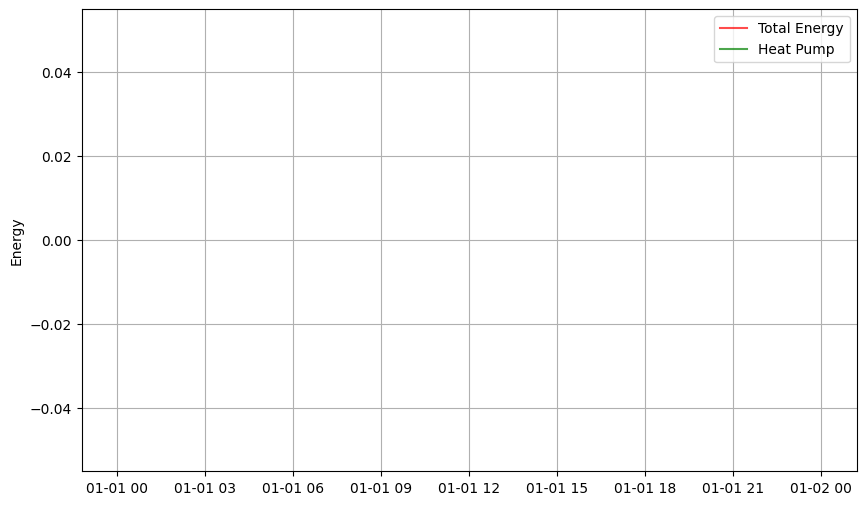

In [11]:
from datetime import datetime 
import matplotlib.pyplot as plt

file_path = "datasets/German/German_15min.hdf5"
with pd.HDFStore(file_path) as store:
    print(store.keys())

df = pd.read_hdf(file_path, key='/NO_PV/SFH5/HEATPUMP')
df2 = pd.read_hdf(file_path, key='/NO_PV/SFH5/HOUSEHOLD')

df.index = pd.to_datetime(df.index, unit='s')
df.index.name = 'timestamp'

df = df[df.first_valid_index():]
first_non_zero_idx = df['S_TOT'].ne(0).idxmax()
df = df.loc[first_non_zero_idx:]


df2.index = pd.to_datetime(df2.index, unit='s')
df2.index.name = 'timestamp'
df2 = df2[df2.first_valid_index():]
first_non_zero_idx = df2['P_TOT'].ne(0).idxmax()
df2 = df2.loc[first_non_zero_idx:]
df2['heat_pump'] = df['P_TOT']
df2['total_energy'] = df2['P_TOT'] + df2['heat_pump']

start_date = "2018-09-02"
end_date = "2018-09-04"
df_plot = df.loc[start_date:end_date]
df2_plot = df2.loc[start_date:end_date]
plt.figure(figsize=(10,6))
plt.plot(df2_plot.index, df2_plot['total_energy'], label='Total Energy', color='red', alpha=0.7)
plt.plot(df2_plot.index, df2_plot['heat_pump'], label='Heat Pump', color='green', alpha=0.7)

plt.legend()
plt.ylabel('Energy')
plt.grid()
plt.show()

In [12]:

file_path_weather = "datasets/German/2018_weather.hdf5"
with pd.HDFStore(file_path_weather) as store:
    print(store.keys())

df_weather = pd.read_hdf(file_path_weather, key='/WEATHER_SERVICE/IN/WEATHER_APPARENT_TEMPERATURE_TOTAL')
df_weather = df_weather.to_frame(name='temperature')
df_weather.index.name = 'timestamp'

print(df_weather.index.min(), '→', df_weather.index.max())
print(f"Total days: {(df_weather.index.max() - df_weather.index.min()).days}")
print(df_weather.shape)
print(df_weather.index.to_series().diff().value_counts().head())
df_weather = df_weather[~df_weather.index.duplicated(keep='first')]

df_weather = df_weather.sort_index()

df_weather_15min = df_weather.resample('15T').interpolate('linear')
df2['Tout'] = df_weather_15min['temperature'].reindex(df2.index)
df2['Tout'] = df2['Tout'].ffill().bfill()
print(df2[['total_energy', 'Tout']].head())
print(df2['Tout'].isna().sum())  


['/WEATHER_SERVICE/IN/WEATHER_APPARENT_TEMPERATURE_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_ATMOSPHERIC_PRESSURE_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_PRECIPITATION_RATE_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_PROBABILITY_OF_PRECIPITATION_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_RELATIVE_HUMIDITY_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_SOLAR_IRRADIANCE_GLOBAL', '/WEATHER_SERVICE/IN/WEATHER_TEMPERATURE_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_WIND_DIRECTION_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_WIND_GUST_SPEED_TOTAL', '/WEATHER_SERVICE/IN/WEATHER_WIND_SPEED_TOTAL']
2018-01-01 00:00:00 → 2018-12-31 23:00:00
Total days: 364
(49028, 1)
timestamp
0 days 00:05:00    39977
0 days 01:00:00     5323
0 days 00:01:00     3535
0 days 00:10:00       85
0 days 00:00:00       40
Name: count, dtype: int64
                     total_energy       Tout
timestamp                                   
2018-05-03 15:30:00      6.554333  16.550000
2018-05-03 15:45:00    462.498334  16.375000
2018-05-03 16:00:00    448.687569  16.2

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\tables\path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'APPARENT_TEMPERATURE:TOTAL'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7604\326734904.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_weather_15min = df_weather.resample('15T').interpolate('linear')


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['max_Tout'] = df['Tout'].rolling(window=window_daily).max().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['min_Tout'] = df['Tout'].rolling(window=window_daily).min().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['avg_Tout'] = df['Tout'].rolling(window=window_daily).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:23: FutureWarning: Series.fillna with 'method' is deprecated

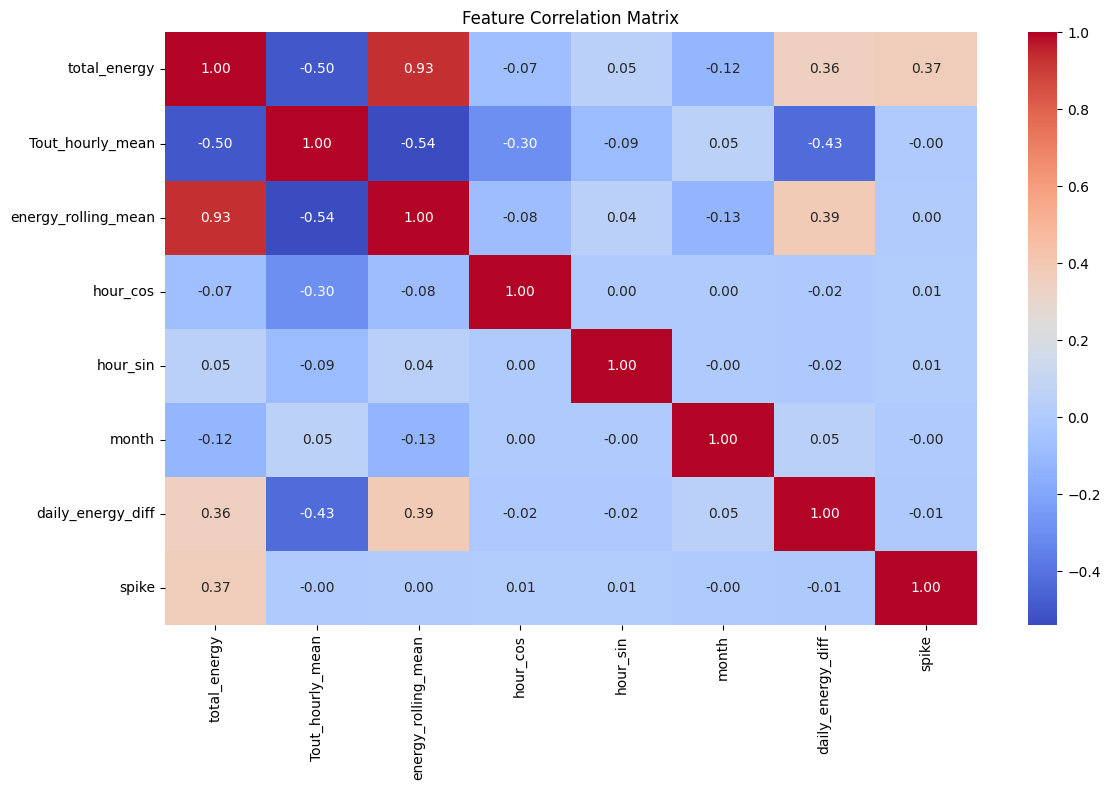

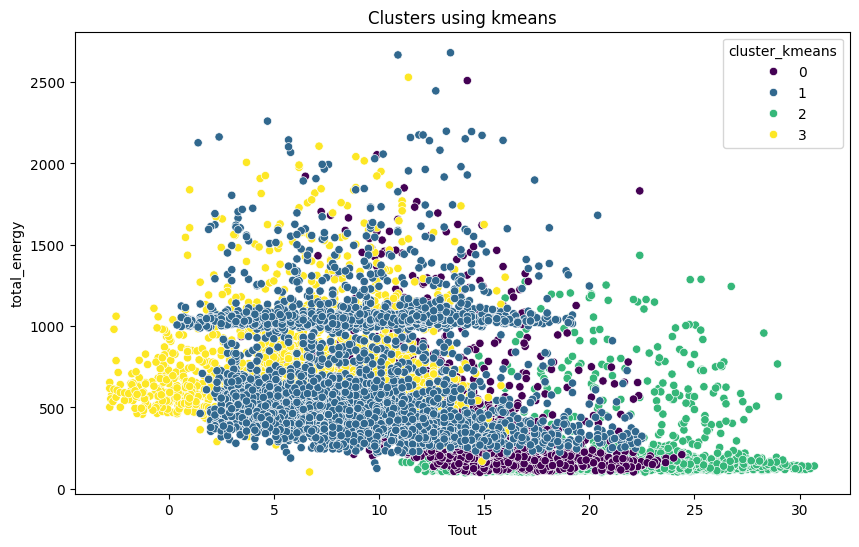

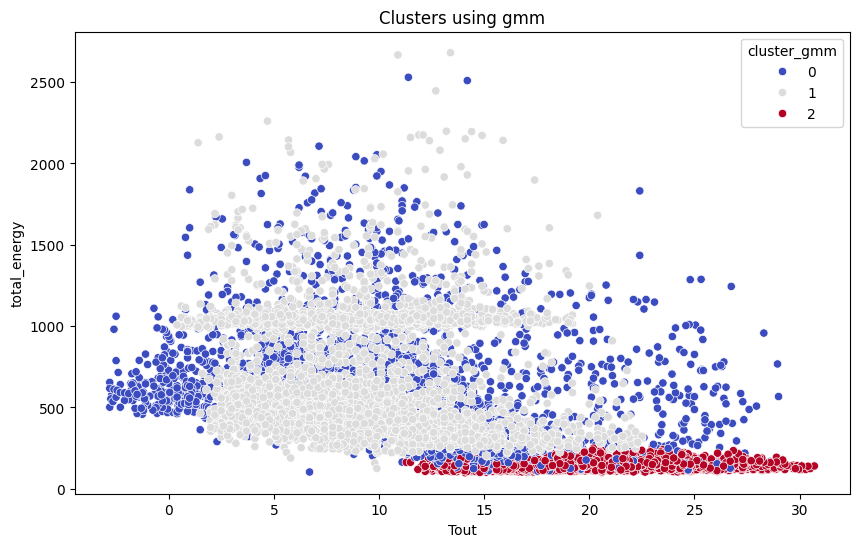

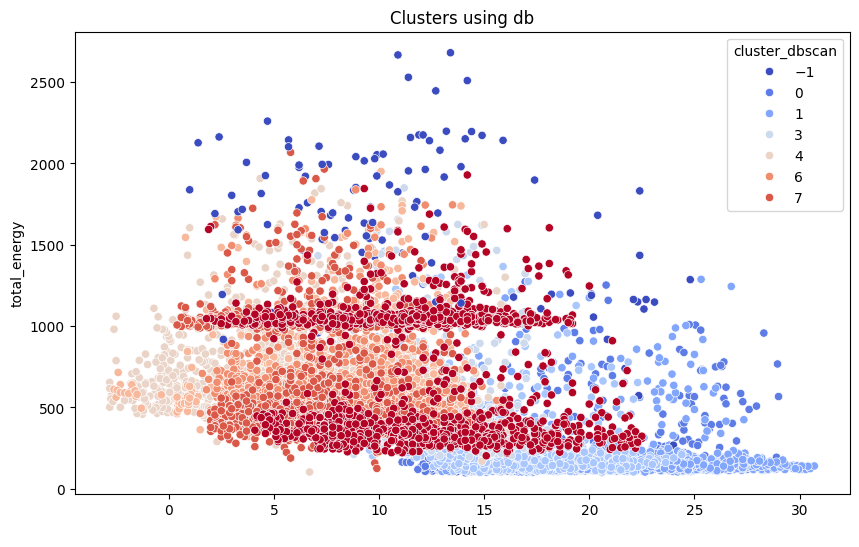

                     total_energy   Tout        Tin         RH  hour  \
timestamp                                                              
2024-06-30 21:00:00        186.27  14.20  28.840046  28.836597    21   
2024-06-30 21:30:00        117.00  14.05  28.868720  33.729145    21   
2024-06-30 22:00:00        132.63  13.90  29.099665  36.758504    22   
2024-06-30 22:30:00        142.20  13.80  29.250277  38.590410    22   
2024-06-30 23:00:00        105.00  13.70  29.352610  39.736028    23   

                     hour_sin  hour_cos  max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                               ...   
2024-06-30 21:00:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 21:30:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 22:00:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 22:30:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 23:00:00 -

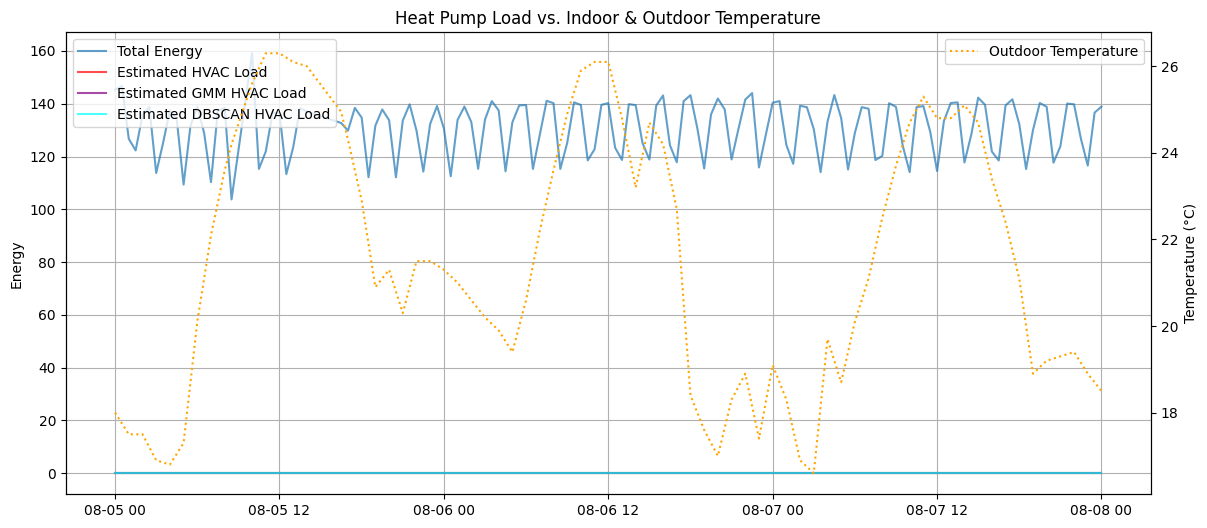

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['max_Tout'] = df['Tout'].rolling(window=window_daily).max().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['min_Tout'] = df['Tout'].rolling(window=window_daily).min().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['avg_Tout'] = df['Tout'].rolling(window=window_daily).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:23: FutureWarning: Series.fillna with 'method' is deprecated

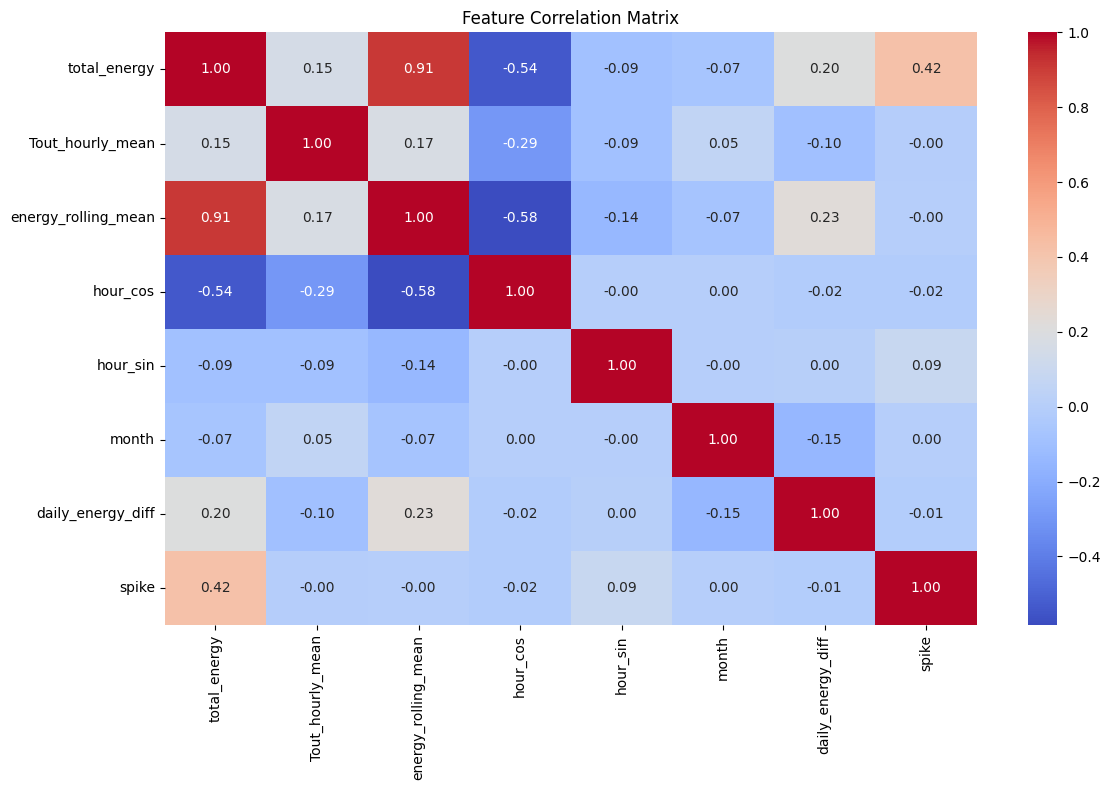

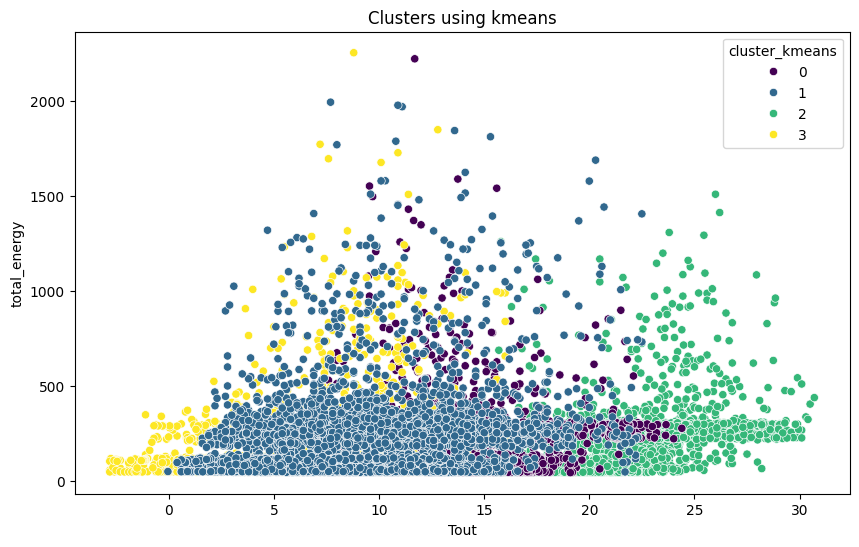

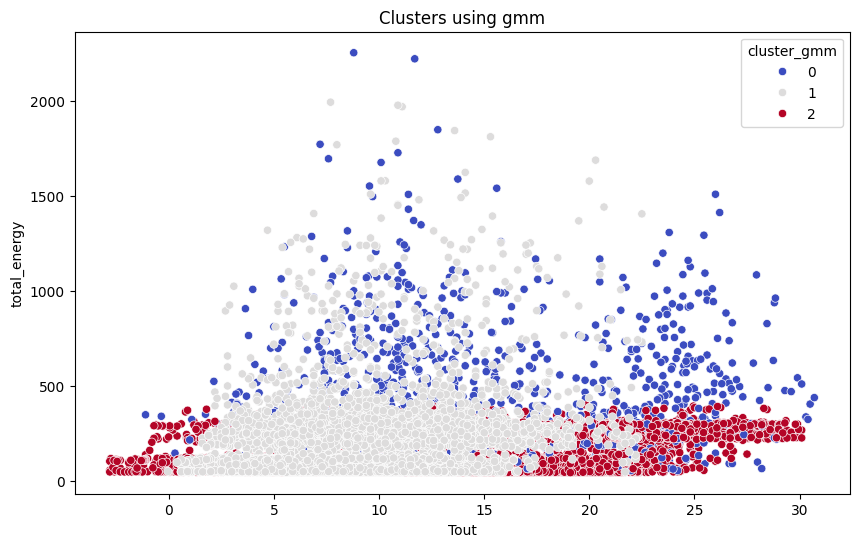

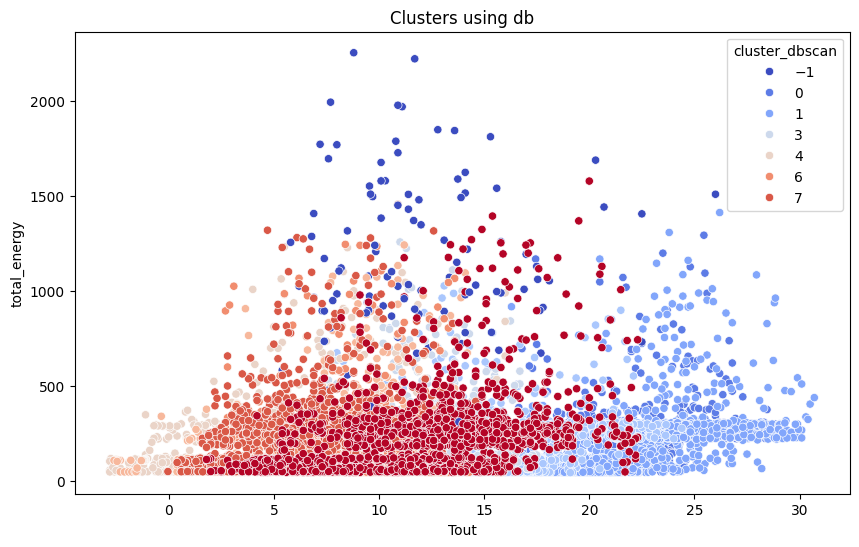

                     total_energy   Tout        Tin         RH  hour  \
timestamp                                                              
2024-06-30 21:00:00         46.68  14.20  29.003444  55.764302    21   
2024-06-30 21:30:00        109.43  14.05  28.994388  56.004746    21   
2024-06-30 22:00:00        101.21  13.90  28.916639  56.443324    22   
2024-06-30 22:30:00         47.00  13.80  28.946221  56.464367    22   
2024-06-30 23:00:00         77.97  13.70  28.852720  56.820143    23   

                     hour_sin  hour_cos  max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                               ...   
2024-06-30 21:00:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 21:30:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 22:00:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 22:30:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 23:00:00 -

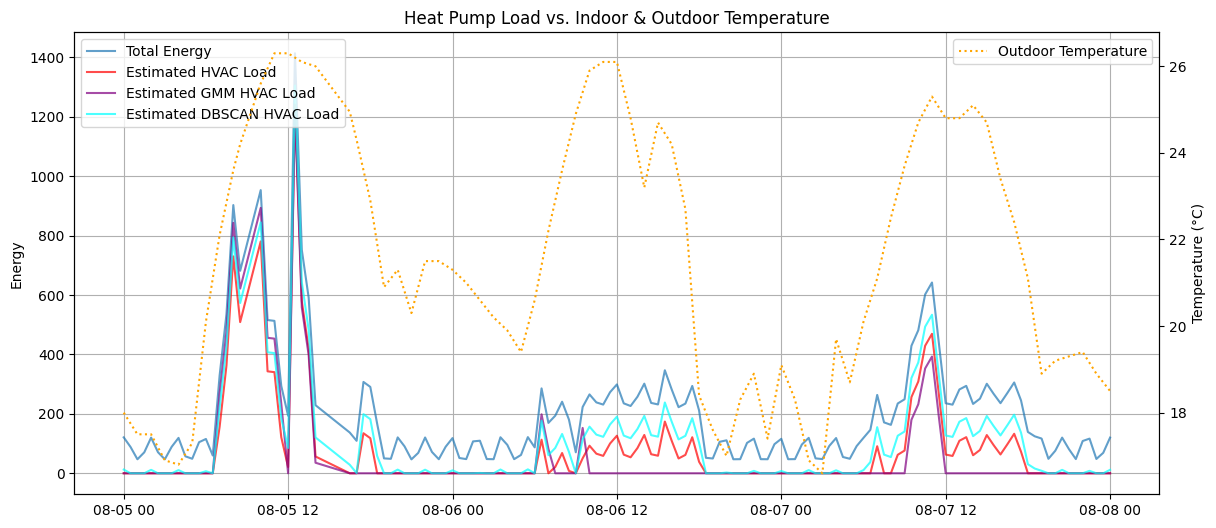

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['max_Tout'] = df['Tout'].rolling(window=window_daily).max().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['min_Tout'] = df['Tout'].rolling(window=window_daily).min().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['avg_Tout'] = df['Tout'].rolling(window=window_daily).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:23: FutureWarning: Series.fillna with 'method' is deprecated

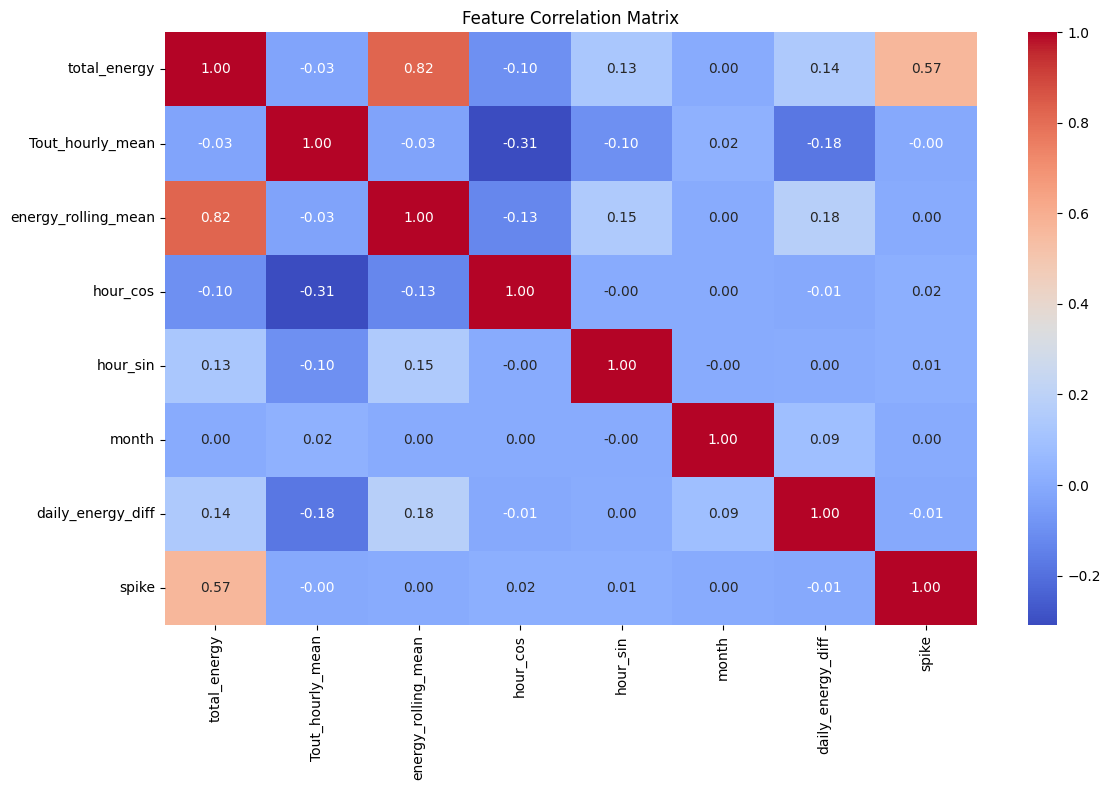

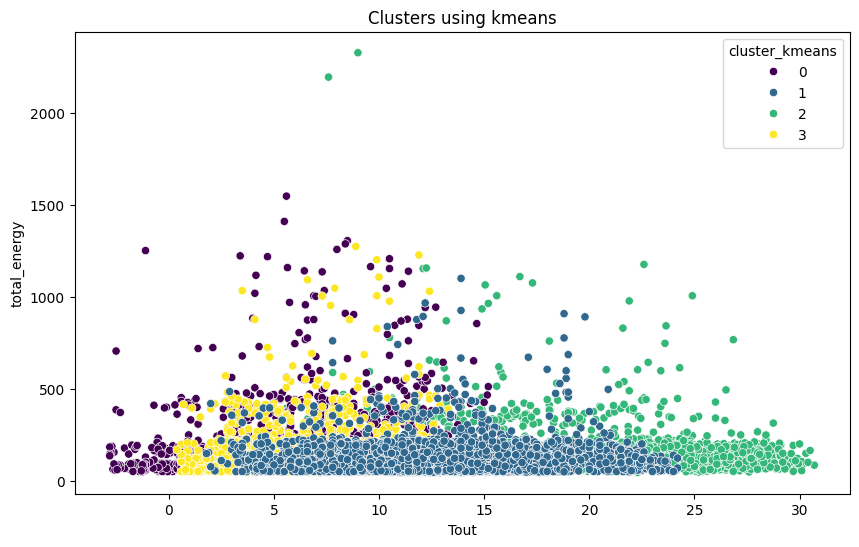

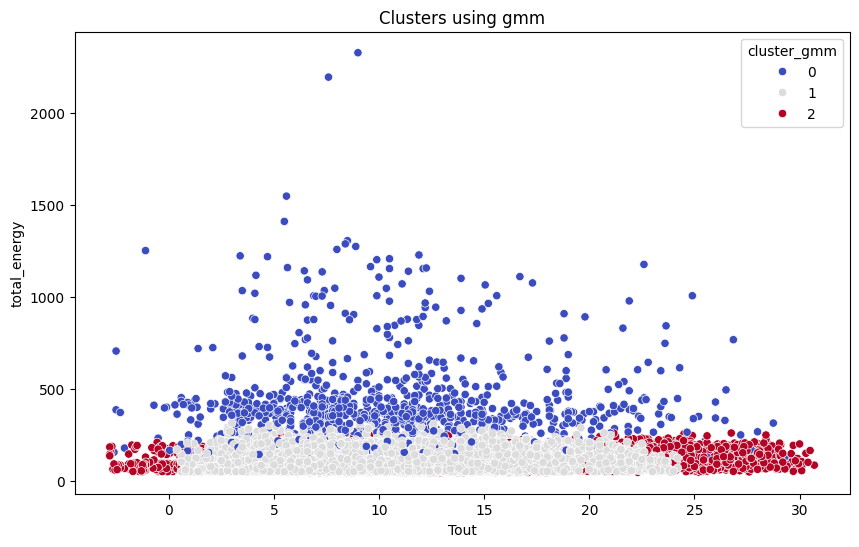

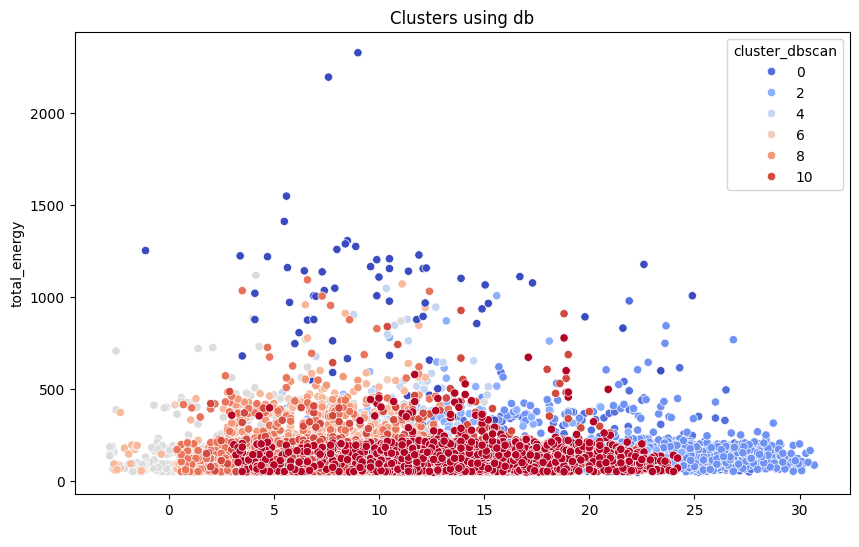

                     total_energy   Tout        Tin         RH  hour  \
timestamp                                                              
2024-06-30 21:00:00        101.74  14.20  27.139997  59.180134    21   
2024-06-30 21:30:00         90.40  14.05  27.151998  59.365436    21   
2024-06-30 22:00:00         75.69  13.90  27.168164  59.389459    22   
2024-06-30 22:30:00        103.80  13.80  27.163442  59.496953    22   
2024-06-30 23:00:00        110.33  13.70  27.159609  59.649898    23   

                     hour_sin  hour_cos  max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                               ...   
2024-06-30 21:00:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 21:30:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 22:00:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 22:30:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 23:00:00 -

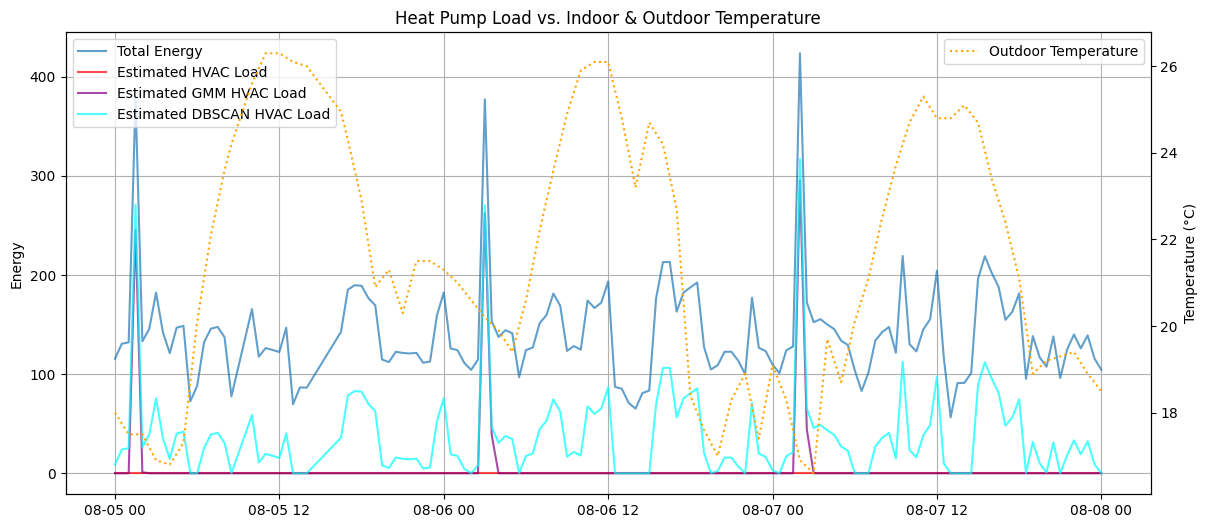

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['max_Tout'] = df['Tout'].rolling(window=window_daily).max().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['min_Tout'] = df['Tout'].rolling(window=window_daily).min().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['avg_Tout'] = df['Tout'].rolling(window=window_daily).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_23684\4083986901.py:23: FutureWarning: Series.fillna with 'method' is deprecated

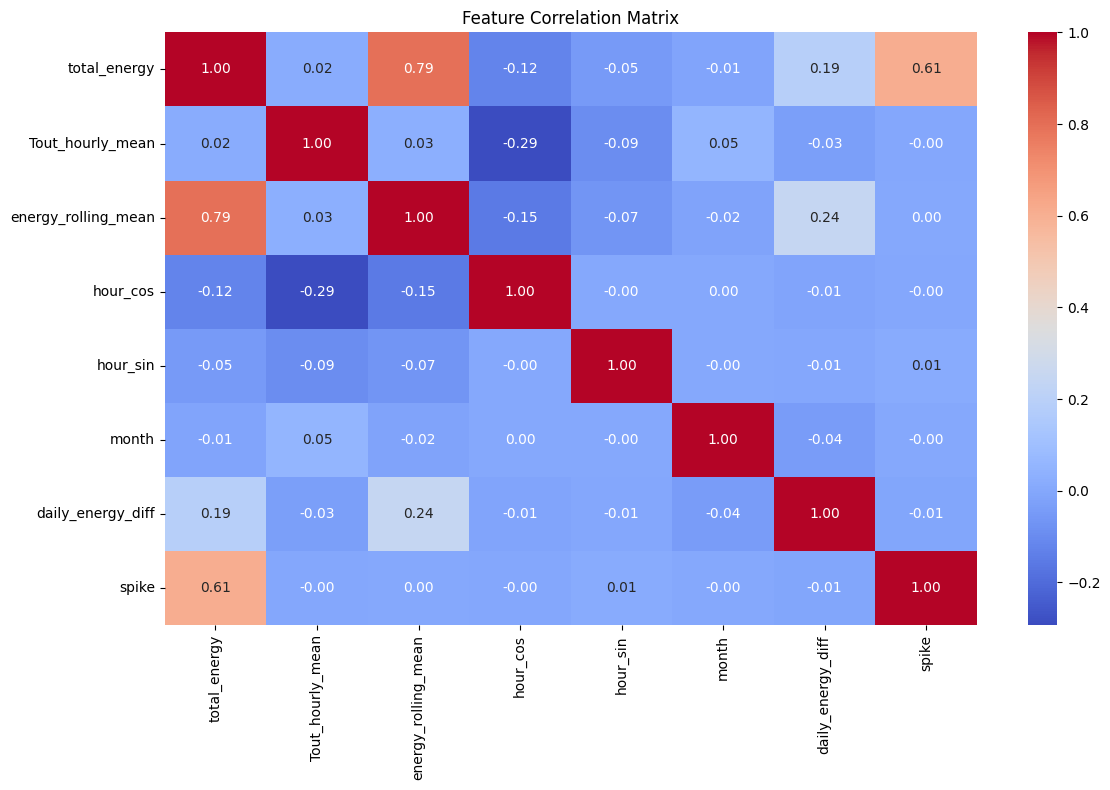

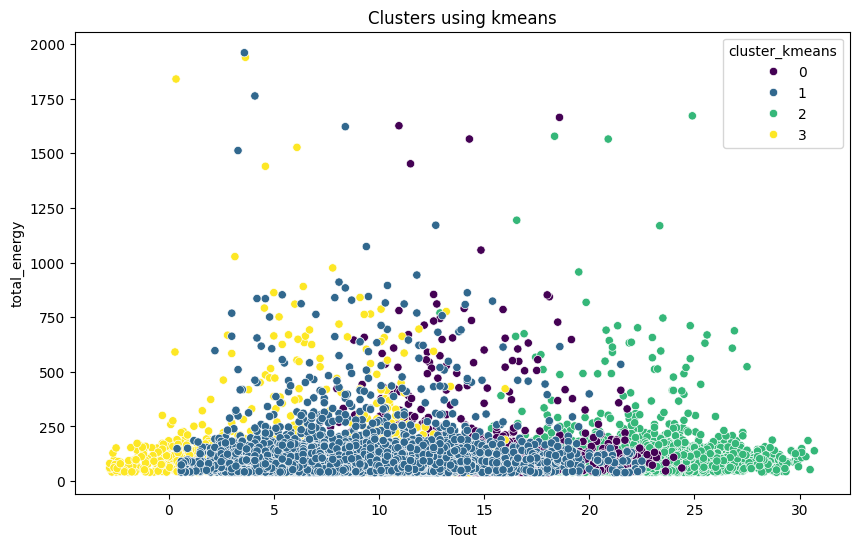

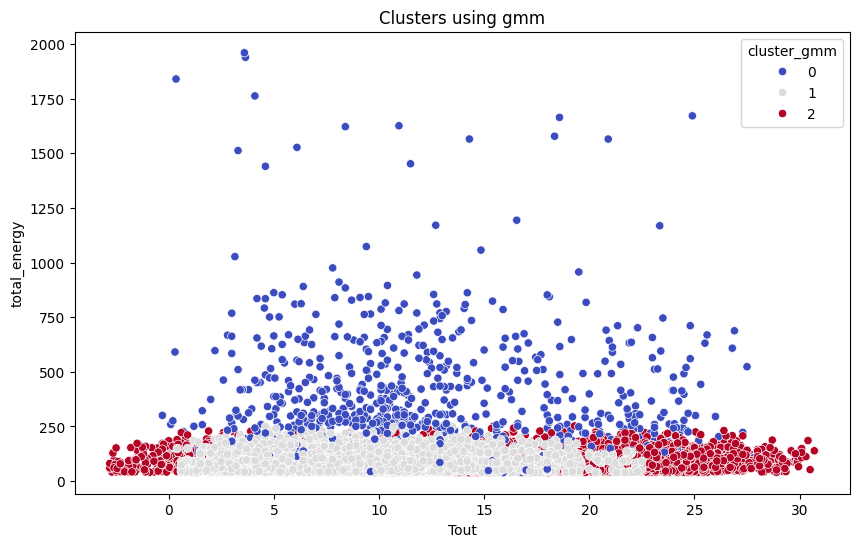

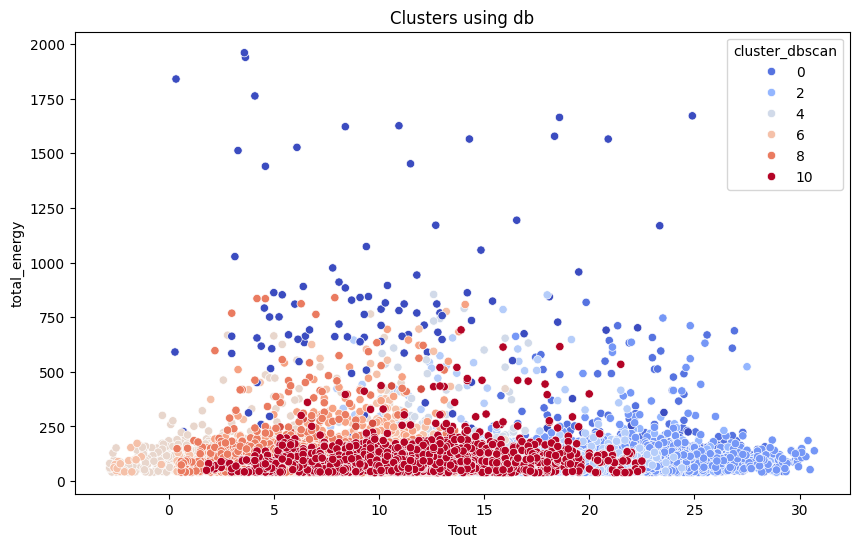

                     total_energy   Tout        Tin         RH  hour  \
timestamp                                                              
2024-06-30 21:00:00        128.47  14.20  27.082225  52.906953    21   
2024-06-30 21:30:00        113.97  14.05  27.234387  52.965861    21   
2024-06-30 22:00:00         41.00  13.90  27.337776  53.218004    22   
2024-06-30 22:30:00        112.70  13.80  27.404554  53.415657    22   
2024-06-30 23:00:00         42.03  13.70  27.465125  53.835187    23   

                     hour_sin  hour_cos  max_Tout  min_Tout   avg_Tout  ...  \
timestamp                                                               ...   
2024-06-30 21:00:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 21:30:00 -0.707107  0.707107      18.9      12.5  15.542708  ...   
2024-06-30 22:00:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 22:30:00 -0.500000  0.866025      18.9      12.5  15.542708  ...   
2024-06-30 23:00:00 -

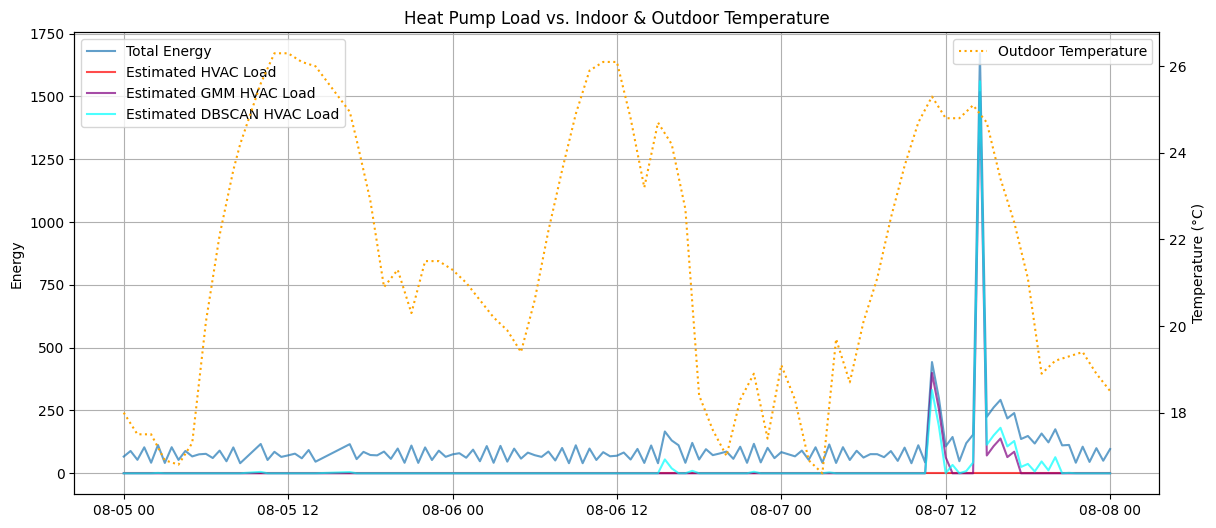

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import os

def extract_hvac(df2, file, window_daily=96, window_hourly=4, ground_truth = False):
    df = df2.copy()
    # print(df.head())
    if ground_truth:
        df = df[['total_energy', 'heat_pump', 'Tout']]
    else:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.drop(columns=['Unnamed: 0'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df = df.sort_index()
        df = df[['total_energy', 'Tout', 'Tin', 'RH']]

    df['hour'] = df.index.hour 
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24) 
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    df['max_Tout'] = df['Tout'].rolling(window=window_daily).max().fillna(method='bfill')
    df['min_Tout'] = df['Tout'].rolling(window=window_daily).min().fillna(method='bfill')
    df['avg_Tout'] = df['Tout'].rolling(window=window_daily).mean().fillna(method='bfill')
    df['Tout_hourly_mean'] = df['Tout'].rolling(window=window_hourly).mean().fillna(method='bfill')
    df['Tout_std'] = df['Tout'].rolling(window=window_hourly).std().fillna(method='bfill')

    df['total_energy_smoothed'] = df['total_energy'].rolling(window=window_daily, center=True, min_periods=1).median().fillna(method='bfill')
    df['energy_rolling_mean'] = df['total_energy'].rolling(window=window_hourly).median().fillna(method='bfill')
    df['energy_daily'] = df['total_energy'].rolling(window=window_daily).mean().ffill().fillna(method='bfill')
    df['energy_rolling_std'] = df['total_energy'].rolling(window=window_hourly, min_periods=1).std().fillna(0)
    df['is_weekend'] = df.index.weekday.isin([5, 6]).astype(int)
    df['season'] = df.index.month.map({1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3, 12: 0})
    df['month'] = df.index.month
    df['spike'] = df['total_energy'].diff().fillna(method='bfill')
    df['total_energy_max'] = df['total_energy'].rolling(window=window_daily).max().fillna(method='bfill')
    df['total_energy_min'] = df['total_energy'].rolling(window=window_daily).min().fillna(method='bfill')
    df['daily_energy_diff'] = df['total_energy_max'] - df['total_energy_min']

    scaled_cols = ['Tout', 'total_energy', 'Tout_hourly_mean', 'min_Tout', 'max_Tout','energy_rolling_mean', 'Tout_std', 'energy_rolling_std', 'total_energy_smoothed','spike','total_energy_min', 'total_energy_max', 'daily_energy_diff']
    features = ['total_energy', 'Tout_hourly_mean', 'energy_rolling_mean', 'hour_cos', 'hour_sin', 'month', 'daily_energy_diff', 'spike']
    df.dropna(subset=['total_energy'], inplace=True)

    df = preprocess_data(df, True, custom_scaled_cols=scaled_cols)

    df, kmeans_model = apply_kmeans(df, features, 4)
    df, gmm_model = apply_gmm(df, features, 3)
    df, dbscan_model = apply_dbscan(df, features, eps=0.32, min_samples=8)

    df = inverse_transform(df, scaled_cols)

    df = estimate_hvac_load(df)

    plt.figure(figsize=(12,8))
    corr_matrix = df[features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

    if ground_truth:
        df['residual'] = df['heat_pump'] - df['hvac_load']

        plt.figure(figsize=(14,6))
        df['residual'].plot(alpha=0.7)
        plt.axhline(0, color='black', linestyle='--')
        plt.title('Residuals (Actual - Predicted Heat Pump Consumption)')
        plt.xlabel('Time')
        plt.ylabel('Residual (kWh)')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10,6))
        sns.scatterplot(x='Tout', y='residual', data=df, alpha=0.3)
        plt.axhline(0, color='red', linestyle='--')
        plt.title('Residual vs. Outdoor Temperature (Tout)')
        plt.xlabel('Outdoor Temperature (Tout)')
        plt.ylabel('Residual (Actual - Predicted)')
        plt.tight_layout()
        plt.show()

        baseline_cluster = df.groupby('cluster_kmeans')['total_energy'].mean().idxmin()

        print(f"Baseline cluster identified: {baseline_cluster}")

        cluster_means = df.groupby('cluster_kmeans')[['total_energy', 'heat_pump']].mean()
        print("\nCluster Means (Total Energy vs Actual Heat Pump):")
        print(cluster_means)

        baseline_hp_ratio = cluster_means.loc[baseline_cluster, 'heat_pump'] / cluster_means.loc[baseline_cluster, 'total_energy']
        print(f"\nRatio of actual heat pump in baseline cluster: {baseline_hp_ratio:.2%}")

    plot_clusters(df, True, method='kmeans')
    plot_clusters(df, True, method='gmm')
    plot_clusters(df, True, method='db')
    print(df.head())
    plot_hvac_load(df, True, '2024-08-05', '2024-08-08')
    df.to_csv(f"datasets/madalena_processed_30min/{file}")

def plot_errors(df, pred_column):
    # df = df.loc['2018-06-01':'2018-11-30']
    df_eval = df.dropna(subset=['heat_pump',pred_column])

    mae = mean_absolute_error(df_eval['heat_pump'], df_eval[pred_column])

    rmse = np.sqrt(mean_squared_error(df_eval['heat_pump'], df_eval[pred_column]))
    mape = mean_absolute_percentage_error(df_eval['heat_pump'], df_eval[pred_column]) * 100
    r2 = r2_score(df_eval['heat_pump'], df_eval[pred_column])
    print(f"R² score: {r2}")
    print(f"MAPE: {mape}%")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")

    mean_consumption = df_eval['heat_pump'].mean()
    mae_relative = mae / mean_consumption
    rmse_relative = rmse / mean_consumption

    print(f"Relative MAE: {mae_relative:.2%}")
    print(f"Relative RMSE: {rmse_relative:.2%}")

    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=df_eval['heat_pump'], y=df_eval[pred_column], alpha=0.6)
    plt.plot([df_eval['heat_pump'].min(), df_eval['heat_pump'].max()], 
            [df_eval['heat_pump'].min(), df_eval['heat_pump'].max()], 
            'r--', lw=2)
    plt.xlabel('Actual Heat Pump Consumption')
    plt.ylabel('Predicted HVAC Load')
    plt.title('Predictions vs Actual Values')
    plt.grid(True)
    plt.show()

    monthly_mean = df['heat_pump'].resample('M').mean().ffill()
    monthly_mean_preds = df[pred_column].resample('M').mean().ffill()

    # Plot
    plt.figure(figsize=(12,6))
    monthly_mean.plot(marker='o', linewidth=2, label='Actual Heat Pump')
    monthly_mean_preds.plot(marker='s', linewidth=2, label='Predicted HVAC Load')

    plt.title('Monthly Mean Heat Pump Consumption: Actual vs Predicted')
    plt.xlabel('Month')
    plt.ylabel('Mean Consumption')
    plt.legend()
    plt.grid(True)
    plt.show()

file_path = "datasets/madalena_processed_30min"
for file in os.listdir(file_path):
    if file == "E_152.csv":
        continue
    df = pd.read_csv(f"{file_path}/{file}")
    extract_hvac(df, file, window_daily=48, window_hourly=2, ground_truth=False)
    # plot_errors(df, 'hvac_load')
    # plot_errors(df, 'hvac_load_gmm')
    # plot_errors(df, 'hvac_load_db')


Classification Report:

              precision    recall  f1-score   support

           0      0.909     0.948     0.928     11409
           1      0.935     0.887     0.910      9613

    accuracy                          0.920     21022
   macro avg      0.922     0.918     0.919     21022
weighted avg      0.921     0.920     0.920     21022



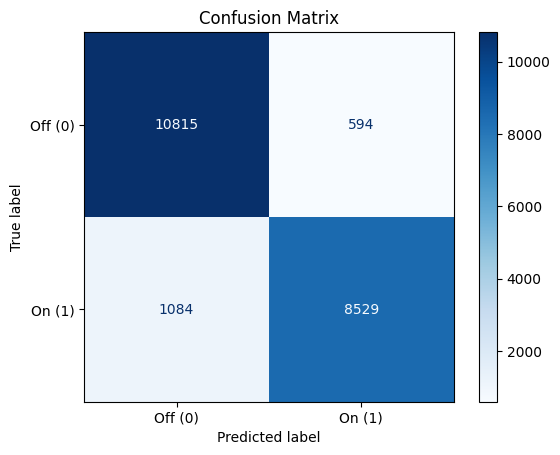

In [72]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
df['active'] = (df['heat_pump'] > 100).astype(int)
df['active_preds'] = (df['hvac_load'] > 100).astype(int)

df['active'] = df['active'].astype(int)
df['active_preds'] = df['active_preds'].astype(int)

print("Classification Report:\n")
print(classification_report(df['active'], df['active_preds'], digits=3))

cm = confusion_matrix(df['active'], df['active_preds'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Off (0)", "On (1)"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [28]:
df_sample = df.loc['2018-12-01':'2018-12-04']
df_sample.to_csv('datasets/testtt.csv')

In [76]:
df_uk = pd.read_csv('datasets/eoh_cleaned_half_hourly.csv')
df_uk.head()

,Property_ID,Timestamp,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Internal_Air_Temperature,Hot_Water_Flow_Temperature,Immersion_Heater_Energy_Consumed,Back-up_Heater_Energy_Consumed,Brine_Flow_Temperature,Brine_Return_Temperature
0,EOH1191,2021-07-08 15:00:00,15:00:00,0.000,0.000,0.000,0.000,20.50,21.65,21.62,NaN,NaN,NaN,NaN,NaN,NaN
1,EOH1191,2021-07-08 15:30:00,15:30:00,4.497,0.024,0.069,0.063,20.50,31.96,32.80,21.34,NaN,NaN,NaN,NaN,NaN
2,EOH1191,2021-07-08 16:00:00,16:00:00,4.652,0.033,0.393,0.200,20.36,37.58,34.53,21.39,NaN,NaN,NaN,NaN,NaN
3,EOH1191,2021-07-08 16:30:00,16:30:00,4.652,0.033,0.393,0.205,20.06,33.86,30.96,21.24,NaN,NaN,NaN,NaN,NaN
4,EOH1191,2021-07-08 17:00:00,17:00:00,4.652,0.033,0.393,0.209,19.57,29.84,28.75,21.23,NaN,NaN,NaN,NaN,NaN


In [86]:
print(df_uk['Property_ID'].unique())
df_uk_1 = df_uk[df_uk['Property_ID'] == 'EOH2232']
df_uk_1.shape

['EOH1191' 'EOH1237' 'EOH2232' 'EOH0645' 'EOH0651' 'EOH1171' 'EOH0311'
 'EOH1977' 'EOH0791' 'EOH1687' 'EOH3183' 'EOH1826' 'EOH0857' 'EOH2994'
 'EOH0043' 'EOH0818' 'EOH2205' 'EOH0955' 'EOH2122' 'EOH1701' 'EOH0582'
 'EOH2179' 'EOH3120' 'EOH0222' 'EOH0310' 'EOH0702' 'EOH2483' 'EOH0459'
 'EOH1839' 'EOH0432' 'EOH2468' 'EOH2980' 'EOH0505' 'EOH0953' 'EOH1426'
 'EOH1334' 'EOH0856' 'EOH1675' 'EOH1576' 'EOH2313' 'EOH2276' 'EOH1792'
 'EOH2630' 'EOH2712' 'EOH2808' 'EOH1783' 'EOH2499' 'EOH0923' 'EOH0957'
 'EOH1360' 'EOH2722' 'EOH3097' 'EOH0524' 'EOH0335' 'EOH0295' 'EOH0047'
 'EOH0465' 'EOH0988' 'EOH2421' 'EOH0323' 'EOH2982' 'EOH0570' 'EOH0596'
 'EOH2025' 'EOH1590' 'EOH1965' 'EOH3033' 'EOH1085' 'EOH2690' 'EOH1794'
 'EOH2149' 'EOH0119' 'EOH2291' 'EOH0424' 'EOH0793' 'EOH2004' 'EOH0534'
 'EOH0937' 'EOH2125' 'EOH0525' 'EOH0979' 'EOH0689' 'EOH2700' 'EOH0830'
 'EOH2390' 'EOH1944' 'EOH2578' 'EOH0577' 'EOH0669' 'EOH2192' 'EOH0562'
 'EOH1214' 'EOH1662' 'EOH0568' 'EOH1485' 'EOH0073' 'EOH0859' 'EOH2155'
 'EOH0

(39767, 16)

In [87]:
df_uk_1['Timestamp'] = pd.to_datetime(df_uk_1['Timestamp'])
df_uk_1.set_index('Timestamp', inplace=True)
df_uk_1 = df_uk_1.sort_index()
df_uk_1 = df_uk_1.loc['2022-01-01':'2022-12-31']

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7604\3628362630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uk_1['Timestamp'] = pd.to_datetime(df_uk_1['Timestamp'])


In [88]:
df_uk_1.head(1000)

,Property_ID,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Internal_Air_Temperature,Hot_Water_Flow_Temperature,Immersion_Heater_Energy_Consumed,Back-up_Heater_Energy_Consumed,Brine_Flow_Temperature,Brine_Return_Temperature
Timestamp,,,,,,,,,,,,,,,
2022-01-01 00:00:00,EOH2232,00:00:00,NaN,6.128,5164.260,2074.643,11.10,21.43,19.39,20.03,NaN,NaN,NaN,NaN,NaN
2022-01-01 00:30:00,EOH2232,00:30:00,NaN,6.128,5164.260,2074.648,11.10,19.88,18.34,19.88,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00,EOH2232,01:00:00,NaN,6.128,5164.260,2074.652,11.12,18.62,17.48,19.75,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:30:00,EOH2232,01:30:00,NaN,6.128,5164.260,2074.656,11.17,17.59,16.78,19.60,NaN,NaN,NaN,NaN,NaN
2022-01-01 02:00:00,EOH2232,02:00:00,NaN,6.128,5164.260,2074.661,11.18,16.76,16.20,19.45,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-21 17:30:00,EOH2232,17:30:00,NaN,7.557,6753.731,2727.873,5.39,52.35,48.07,20.70,NaN,NaN,NaN,NaN,NaN
2022-01-21 18:00:00,EOH2232,18:00:00,NaN,7.560,6756.658,2728.934,5.47,52.93,48.50,20.84,NaN,NaN,NaN,NaN,NaN
2022-01-21 18:30:00,EOH2232,18:30:00,NaN,7.562,6759.620,2730.013,5.48,52.95,48.61,21.03,NaN,NaN,NaN,NaN,NaN


In [25]:
import os
folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        dfs.append(df)

create_comfort_score(dfs)

            timestamps  total_energy  pump_energy  hvac_energy        Tin  \
0  2022-08-14 13:30:00     17.923451          0.0          0.0  26.663333   
1  2022-08-14 13:45:00      9.999323          0.0          0.0  26.565926   
2  2022-08-14 14:00:00     24.090146          0.0          0.0  26.500000   
3  2022-08-14 14:15:00     40.105616          0.0          0.0  26.444444   
4  2022-08-14 14:30:00    221.178375          0.0          0.0  26.332222   

        Tout         RH  month   PMV  PPD  Overall_Comfort  
0  25.855000  43.000000      8  0.36  7.7             92.3  
1  25.663333  43.093333      8  0.33  7.3             92.7  
2  26.318667  43.490000      8  0.31  7.0             93.0  
3  26.343333  43.593333      8  0.29  6.8             93.2  
4  26.945333  43.990000      8  0.26  6.4             93.6  
            timestamps  total_energy  pump_energy  hvac_energy        Tin  \
0  2022-08-14 13:30:00           0.0          0.0          0.0  25.888889   
1  2022-08-14 13:

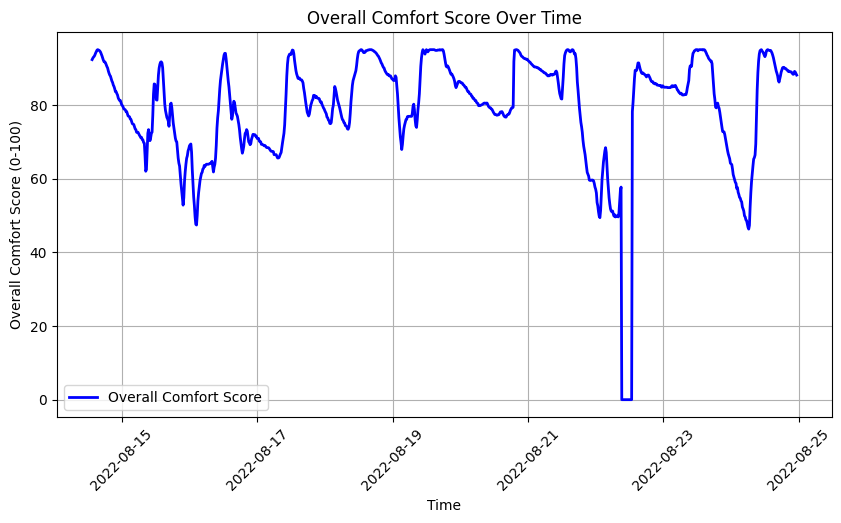

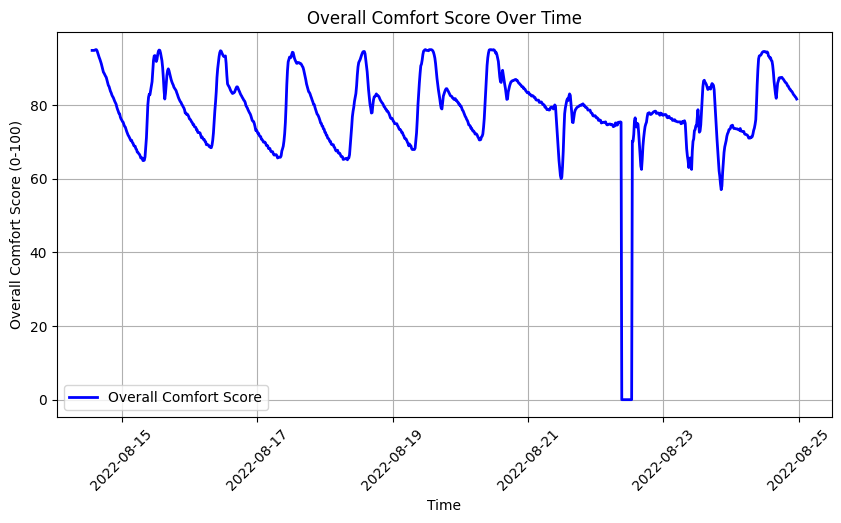

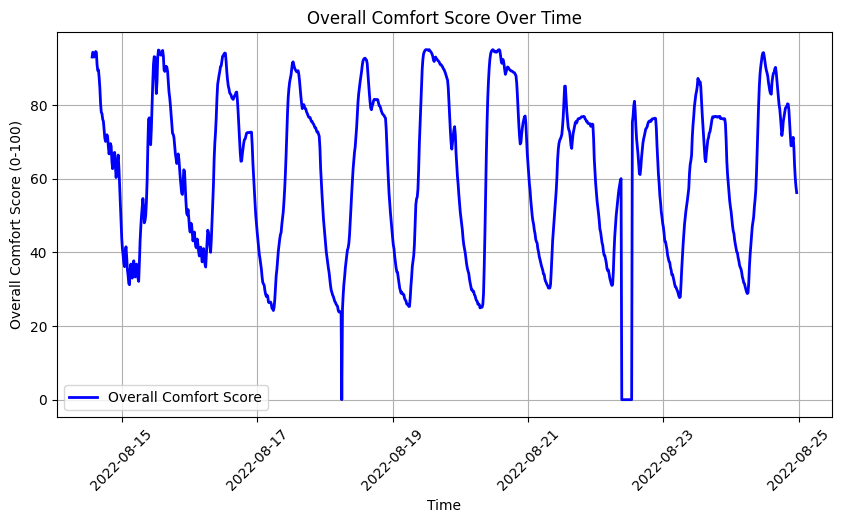

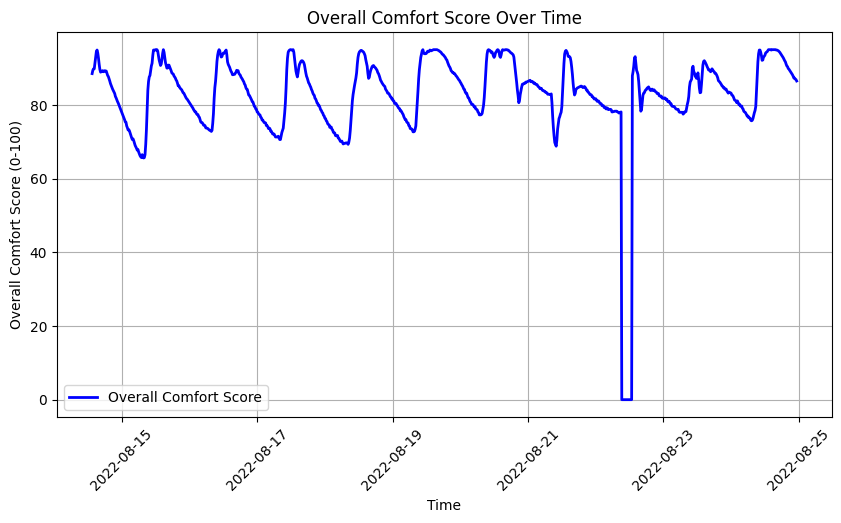

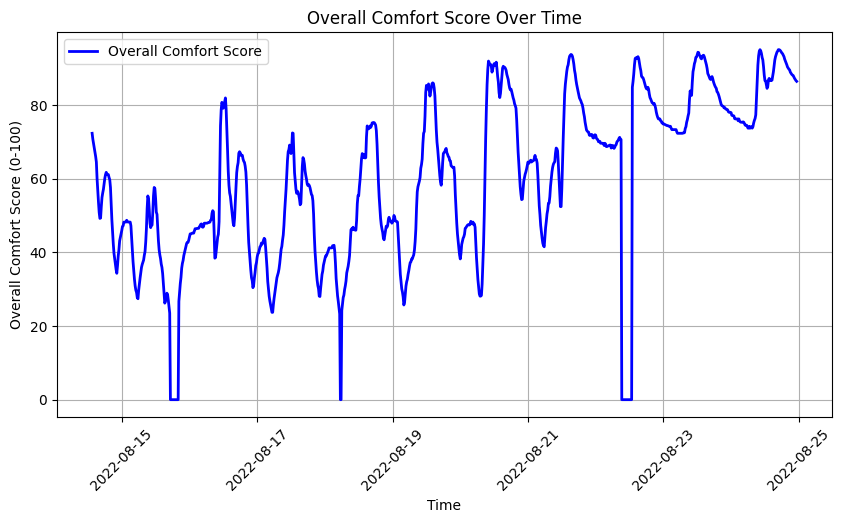

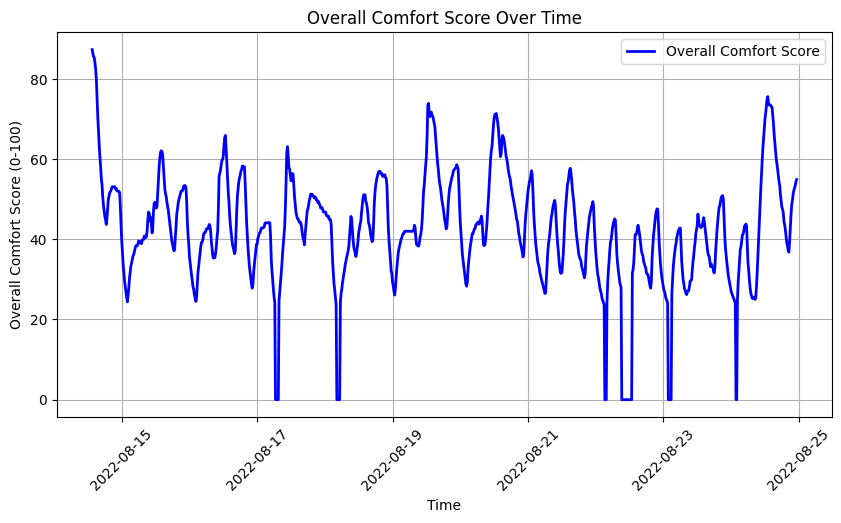

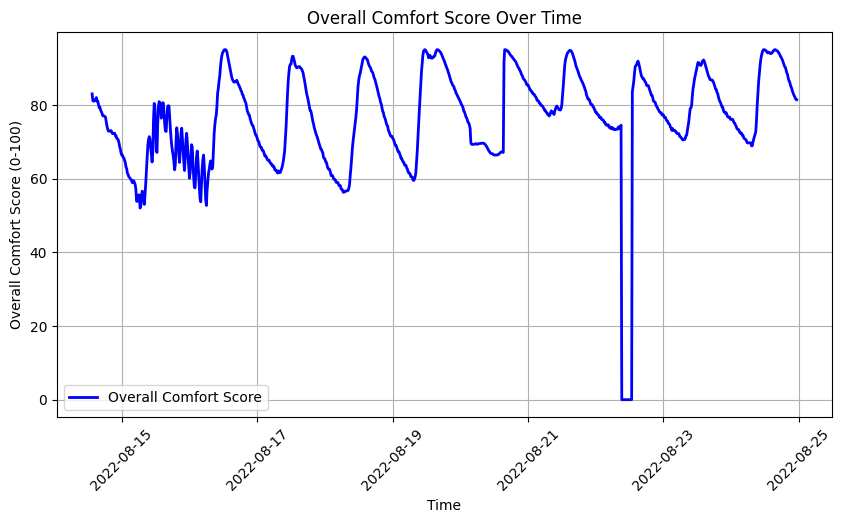

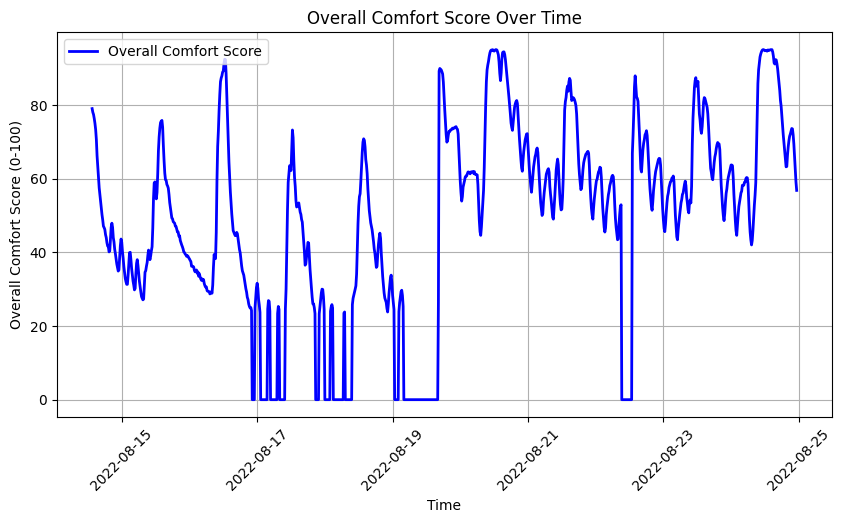

In [26]:
plot_comfort_scores(dfs)
for index,df in enumerate(dfs):
    df.to_csv(f"datasets/retrofit/resampled/resampled_{index}.csv", index=False)